## agent基本用法：绑定工具
### 绑定一个自定义工具

In [2]:
from langchain.agents import create_agent
from dotenv import load_dotenv
import os
from langchain_qwq import ChatQwen
from rich import print as rprint

load_dotenv(override=True)
model = ChatQwen(
    model="deepseek-v4-flash",
    api_base=os.getenv("DASHSCOPE_API_BASE"),  # 国内 Key 必须用国内地址
)

In [3]:
from langchain.tools import tool

@tool(parse_docstring=True)
def get_weather(city: str) -> str:
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}的天气为晴朗，25°C。"

{
    'messages': [
        SystemMessage(
            content='你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。',
            additional_kwargs={},
            response_metadata={},
            id='b81a66a2-7239-43bd-b252-dfe0b4acbc0e'
        ),
        HumanMessage(
            content='北京的天气怎么样？',
            additional_kwargs={},
            response_metadata={},
            id='a0513a56-1903-468d-8e52-f4ee75611689'
        ),
        AIMessage(
            content='好的，我来帮你查询一下北京的天气情况',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': '用户想查询北京的天气情况。我需要使用天气查询工具来获取北京当前的天气信息。'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 74,
                    'prompt_tokens': 305,
                    'total_tokens': 379,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 19,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'dashscope',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-0995920b-aa4c-9306-89a7-93b3742ed95d',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f1b68-f3c2-7771-a654-ddd2b4fee123-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_15d59bf2f99249ab9bad8575',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 305,
                'output_tokens': 74,
                'total_tokens': 379,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 19}
            }
        ),
        ToolMessage(
            content='北京的天气为晴朗，25°C。',
            name='get_weather',
            id='1a444111-0646-4b92-baf7-f21eabf48667',
            tool_call_id='call_15d59bf2f99249ab9bad8575'
        ),
        AIMessage(
            content='北京的天气情况如下：\n\n🌤 **天气：** 晴朗\n🌡 **温度：** 
25°C\n\n天气不错，是个阳光明媚的好天气！请问还有其他城市的天气需要查询吗？',
            additional_kwargs={'refusal': None, 'reasoning_content': '查询到了北京的天气，现在我来回答用户。'},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 54,
                    'prompt_tokens': 379,
                    'total_tokens': 433,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 10,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}
                },
                'model_provider': 'dashscope',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-bd9ce0e8-2083-9f15-b852-aaa57713ddb2',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019f1b68-f80d-7963-885e-0689db66141a-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 379,
                'output_tokens': 54,
                'total_tokens': 433,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {'reasoning': 10}
            }
        )
    ]
}

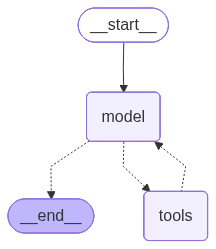

In [4]:
agent = create_agent(
    model,
    tools=[get_weather]
)

resp = agent.invoke({
    "messages": [
        {"role": "system", "content": "你是一个天气查询助手，只回答天气相关的问题，其他问题请直接回答：我不清楚这问题答案。"},
        {"role": "user", "content": "北京的天气怎么样？"}
    ]
})
rprint(resp)
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

In [6]:
from langchain_tavily import TavilySearch

load_dotenv(override=True)

web_search = TavilySearch(
    tavily_api_key=os.getenv("TAVILY_API_KEY"),
    max_results=2
)

#这是一个高度封装的网络搜索工具，可以直接调用：
web_search.invoke("请问2026年足球世界杯有哪些参赛队？")

{'query': '请问2026年足球世界杯有哪些参赛队？',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://baike.baidu.com/item/2026%E5%B9%B4%E5%9B%BD%E9%99%85%E8%B6%B3%E8%81%94%E4%B8%96%E7%95%8C%E6%9D%AF/62863018',
   'title': '2026年国际足联世界杯_百度百科',
   'content': '2026年国际足联世界杯（2026 FIFA World Cup），简称“2026年美加墨世界杯”，该届赛事于2026年6月11日至7月19日在美国、加拿大与墨西哥三国联合举办，是历史上首次由三个国家共同承办，也是北美洲第四次举办该项赛事 [1] [25]。. 2017年4月10日，美国、加拿大和墨西哥足协宣布联合申办，这是世界杯历史上首次由三个国家联合申办 [2]。2018年6月13日，三国获得2026年世界杯主办权 [1] [25]。2022年6月17日确定16座举办城市 [6]。2023年5月18日公布会徽，白色数字26配大力神杯 [10-11] [272]。2025年10月2日，国际足联发布官方比赛用球“三重浪”，该球采用三国文化元素设计并嵌入500赫兹运动传感芯片 [53] [59]；12月7日，FIFA官方公布2026国际足联世界杯的全部赛程 [106]。. 外文名 2026 FIFA World Cup. 举办时间 2026年6月11日 至 2026年7月19日 [16]. 当地时间2017年4月10日，美国、加拿大和墨西哥足协宣布，将联合申办2026年国际足联世界杯。这是世界杯历史上首次由三个国家联合申办 [2]。. 2018年6月13日，国际足联第68次代表大会在莫斯科举行。经过一番投票角逐，美国、加拿大和墨西哥击败非洲国家摩洛哥，获得2026年世界杯的联合主办权 [1] [25]。. 第一档：加拿大、墨西哥、美国、西班牙、阿根廷、法国、英格兰、巴西、葡萄牙、荷兰、比利时、德国；. 🇵🇹 葡萄牙🇨🇩 刚果（金）🇺🇿 乌兹别克斯坦🇨🇴 哥伦比亚. | 捷克国家男子足球队 | 2026年4月1日 |

In [7]:
# 3.创建Agent
agent = create_agent(
    model=model,
    tools=[web_search],
    system_prompt="你是一名多才多艺的智能助手，可以调用工具帮助用户解决问题。"
)
# 4.运行Agent获得结果
result = agent.invoke({"messages": [{"role": "user", "content": "请帮我查询2024年诺贝尔物理学奖得主是谁？"}]}
)
rprint(result)
rprint(result['messages'][-1].content)

{
    'messages': [
        HumanMessage(
            content='请帮我查询2024年诺贝尔物理学奖得主是谁？',
            additional_kwargs={},
            response_metadata={},
            id='7b0923fa-24e6-4661-8359-a5888dc2214c'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': '用户想知道2024年诺贝尔物理学奖得主是谁。我需要搜索这个信息。'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 71,
                    'prompt_tokens': 1824,
                    'total_tokens': 1895,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 17,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'dashscope',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-a2e10e4b-9cab-9952-8359-9ad5f0fdfd8e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f1ba3-fa62-7ce2-80dc-3f799f26fa55-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {'query': '2024年诺贝尔物理学奖得主'},
                    'id': 'call_03ee2f09abff40a0a58ed117',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1824,
                'output_tokens': 71,
                'total_tokens': 1895,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 17}
            }
        ),
        ToolMessage(
            content='{"query": "2024年诺贝尔物理学奖得主", "follow_up_questions": null, "answer": null, "images": 
[], "results": [{"url": "https://news.sciencenet.cn/htmlnews/2024/10/531146.shtm", "title": 
"刚刚，2024年诺贝尔物理学奖揭晓！ - 新闻- 科学网", "content": "| |  | | --- | | 作者：冯丽妃，梅进 
来源：科学网微信公众号 发布时间：2024/10/8 17:52:45  选择字号：小 中  大 | | |  | | --- | |  | |  | | 
刚刚，2024年诺贝尔物理学奖揭晓！ | |  |       
北京时间10月8日下午5点45分许，2024年诺贝尔物理学奖揭晓。美国普林斯顿大学科学家约翰·霍普菲尔德（John J. 
Hopfield创造了一种联想记忆，可以存储和重建图像和其他类型的数据模式。Geoffrey 
Hinton发明了一种方法，可以自动发现数据中的属性，从而执行识别图片中的特定元素等任务。  
当我们谈论人工智能时，我们通常指的是使用人工神经网络的机器学习。这项技术最初是受到大脑结构的启发。在人工神经网络中
，大脑的神经元由具有不同值的节点表示。这些节点通过连接相互影响，这些连接可以被比作突触，可以增强或减弱。例如，通过
在同时具有高值的节点之间建立更强的连接来训练网络。今年的获奖者从20世纪80年代开始就在人工神经网络方面开展了重要的工
作。  John 
Hopfield发明了一种网络，可以使用一种方法来保存和重建模式。我们可以把节点想象成像素。Hopfield网络利用物理学来描述材
料的特性，这是由于它的原子自旋——使每个原子成为微小磁铁的一种特性。整个网络的描述方式相当于物理中发现的自旋系统中的
能量，并通过寻找节点之间的连接值来训练，以便保存的图像具有低能量。当Hopfield网络得到一张扭曲或不完整的图像时，它会
有条不紊地通过节点并更新它们的值，这样网络的能量就会下降。因此，网络逐步找到最像它输入的不完美图像的已存图像。  
Geoffrey 
Hinton使用Hopfield网络作为新网络的基础，它采用了一种不同的方法——玻尔兹曼机。它可以学习识别给定类型数据中的特征元素
。Hinton使用了统计物理学的工具，这是一门由许多相似内容组成的系统科学。通过给机器输入在实际运行时很可能出现的例子来
训练它。玻尔兹曼机器可以用来对图像进行分类，或者为它所训练的模式类型创建新的例子。Hinton在这项工作的基础上，帮助开
启了当前机器学习的爆炸性发展。  
“获奖者的工作已经带来了巨大的好处。在物理学中，我们在广泛的领域使用人工神经网络，例如开发具有特定性能的新材料。”诺
贝尔物理学委员会主席Ellen Moons说。  **获奖者简历**    \xa0\xa0? 
Hinton，1947年出生于英国伦敦。1978年从英国爱丁堡大学获得博士学位。目前为加拿大多伦多大学教授。  
基于人工神经网络实现机器学习的基础性发现和发明。图片来自：瑞典皇家科学院/Johan Jarnestad  **天然和人工神经元**  
大脑的神经网络是由活细胞、神经元和先进的内部机制构成的。它们可以通过突触相互传递信号。当我们学习东西时，一些神经元
之间的联系变得更强，而另一些神经元之间的联系变得更弱。人工神经网络是由带有值编码的节点构建的。节点之间相互连接，当
网络被训练时，同时活跃的节点之间的连接会变得更强，否则则会变弱。   图片来自：瑞典皇家科学院/Johan Jarnestad    
**过去10年诺贝尔物理学奖得主名单**  2023年——美国科学家Pierre Agostini、德国科学家Ferenc Krausz和法国/瑞典科学家Anne
L’Huillier获奖，获奖理由是“开发了产生阿秒光脉冲的实验方法，用于研究物质中的电子动力学”。  
2022年——法美奥三位科学家Alain Aspect、John F. Clauser和Anton 
Zeilinger获奖，获奖理由是“进行了纠缠光子的实验，确立了贝尔不等式的违反，并开创了量子信息科学”。  
2021年——美德意三位科学家因“对人们理解复杂物理系统的开创性贡献”而获奖。美籍日裔科学家Syukuro Manabe、德国科学家Klaus
Hasselmann的获奖理由是“物理模拟地球气候，量化变化和可靠地预测全球变暖”；意大利科学家Giorgio 
Parisi的获奖理由是“发现从原子到行星尺度的物理系统的无

## 2024年诺贝尔物理学奖得主

2024年诺贝尔物理学奖授予了以下两位科学家：

1. **约翰·霍普菲尔德（John J. Hopfield）** —— 美国普林斯顿大学科学家
2. **杰弗里·辛顿（Geoffrey E. Hinton）** —— 加拿大多伦多大学教授

### 🏆 获奖理由
表彰他们 **"为利用人工神经网络进行机器学习做出的基础性发现和发明"**。

### 📌 主要贡献
- **约翰·霍普菲尔德**：发明了**霍普菲尔德网络（Hopfield 
Network）**，这是一种联想记忆网络，可以存储和重建图像及其他类型的数据模式，其原理借鉴了物理学中自旋系统的能量特性。
- **杰弗里·辛顿**：在霍普菲尔德网络基础上发展了**玻尔兹曼机（Boltzmann 
Machine）**，利用统计物理学的工具，使机器能够自动发现数据中的特征，从而识别图片中的特定元素等任务，为当前机器学习的
爆炸性发展奠定了基础。

两位科学家的研究开创了用物理学方法推动人工智能发展的先河，为今天的深度学习技术奠定了重要基石。

{
    'messages': [
        HumanMessage(
            content='你好，杭州今天的天气如何？今天有哪些新闻？',
            additional_kwargs={},
            response_metadata={},
            id='3e0d812b-b733-4cd8-abe3-f314a5a7d4d5'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': 
'用户想知道杭州今天的天气以及今天的新闻。我需要调用两个工具：get_weather（杭州）和get_news。这两个工具没有依赖关系
，可以同时调用。'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 96,
                    'prompt_tokens': 319,
                    'total_tokens': 415,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 35,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}
                },
                'model_provider': 'dashscope',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-6a375577-f64b-91ae-b1db-ad23e55c086f',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f1bc1-8a79-7281-b5c6-c6c18357942e-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_9463366e909b43669a5b8e3e',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_07f547398b3b42ffb0db94ce', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 319,
                'output_tokens': 96,
                'total_tokens': 415,
                'input_token_details': {'cache_read': 256},
                'output_token_details': {'reasoning': 35}
            }
        ),
        ToolMessage(
            content='杭州今天天气挺好',
            name='get_weather',
            id='744f5699-a9e9-46bf-aee2-523b92b16b57',
            tool_call_id='call_9463366e909b43669a5b8e3e'
        ),
        ToolMessage(
            content='近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍
上涨，旧手机成“香饽饽”。',
            name='get_news',
            id='dd01f9f8-74f4-466e-925a-e9416b88a202',
            tool_call_id='call_07f547398b3b42ffb0db94ce'
        ),
        AIMessage(
            content='你好！以下是你的问题回复：\n\n## ☀️ 
杭州今日天气\n杭州今天**天气挺好**的！适合出门活动哦~不过具体的温度、风力等详细信息建议查看专业天气App获取更准确的
数据。\n\n## 📰 今日新闻\n今天的一则重要新闻是：\n\n> **废旧手机回收市场迎来"火热潮"** — 
受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收价格普遍上涨，旧手机成了"香饽饽"。\n\n如果你对某个话题想
了解更多，可以继续问我哦！😊',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': "The user asked two questions: 1) What's the weather like in Hangzhou today? 
2) What are today's news? Let me summarize the results."
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 156,
                    'prompt_tokens': 443,
                    'total_tokens': 599,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 34,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'dashscope',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': None,
                'id': 'chatcmpl-42eb0a0a-f7a4-96cb-974c-2c8997da6fa1',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='l

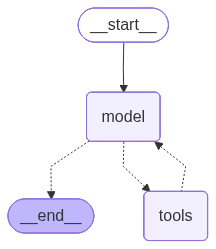

In [10]:
# 多工具绑定
@tool(parse_docstring=True)
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}今天天气挺好"

@tool(parse_docstring=True)
def get_news():
    """
    新闻查询工具
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。"
agent = create_agent(
    model,
    tools=[get_weather, get_news]
)
response = agent.invoke({
    "messages": ["你好，杭州今天的天气如何？今天有哪些新闻？"]
})
rprint(response)

from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 工具调用流程分析
用户问题 → AI 思考 → 调用工具 → 观察结果 → 继续思考 → ... → 最终答案

## 重试机制

Agent 可以在工具返回临时错误时，由模型自主决定是否再次调用工具。

注意：
- 演示里用 `FAIL_BEFORE_SUCCESS` 控制「前 N 次失败、第 N+1 次成功」
- **每次运行前都要重置计数**，否则前面 cell 调用过工具会导致第二次就成功
- `pretty_print()` 输出很长时，Notebook 可能折叠中间内容；代码里会单独打印「工具调用记录」摘要

In [15]:
from langchain.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool

FAIL_BEFORE_SUCCESS = 5  # 前 5 次失败，第 6 次成功

_retry_state = {"count": 0, "logs": []}

@tool
def get_weather(city: str):
    """天气查询工具。

    Args:
        city: 城市名称
    """
    _retry_state["count"] += 1
    attempt = _retry_state["count"]

    if attempt <= FAIL_BEFORE_SUCCESS:
        result = (
            f"TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"
            f"（第 {attempt} 次查询失败，至少还需重试 {FAIL_BEFORE_SUCCESS + 1 - attempt} 次）"
        )
        _retry_state["logs"].append(f"第 {attempt} 次: 失败 -> {result}")
        return result

    result = f"{city}今天天气挺好（第 {attempt} 次查询成功）"
    _retry_state["logs"].append(f"第 {attempt} 次: 成功 -> {result}")
    return result

messages = [
    SystemMessage(
        """你是一个天气助手。
当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，说明是临时故障，不要立即放弃；
你应再次调用同一个工具，直到返回成功结果，或已经连续失败 6 次。
成功后，请根据工具返回内容告诉用户天气，并说明一共调用了工具几次。"""
    ),
    HumanMessage("你好，杭州今天的天气如何？"),
]

# 每次演示前重置，避免前面 cell 的调用次数污染本次结果
_retry_state["count"] = 0
_retry_state["logs"].clear()

agent = create_agent(model, tools=[get_weather])
response = agent.invoke({"messages": messages})

print("=" * 50)
print("工具调用记录（每次 invoke 的实际返回）")
print("=" * 50)
for line in _retry_state["logs"]:
    print(line)
print(f"\n合计调用: {_retry_state['count']} 次\n")

print("=" * 50)
print("完整对话链路（含 AI 思考与 tool call）")
print("=" * 50)
for msg in response["messages"]:
    if isinstance(msg, ToolMessage):
        print(f"\n[ToolMessage] {msg.name}\n{msg.content}\n")
    else:
        msg.pretty_print()

工具实际调用次数: 6

================================ System Message ================================

你是一个天气助手。
当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，说明是临时故障，不要立即放弃；
你应再次调用同一个工具，直到返回成功结果，或已经连续失败 6 次。
成功后，请根据工具返回内容告诉用户天气，并说明一共调用了工具几次。
================================ Human Message =================================

你好，杭州今天的天气如何？
================================== Ai Message ==================================

好的，我来帮你查询杭州今天的天气情况，先调用工具看看！
Tool Calls:
  get_weather (call_0889052fb6504e578f74c8bc)
 Call ID: call_0889052fb6504e578f74c8bc
  Args:
    city: 杭州
================================= Tool Message =================================
Name: get_weather

TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试（第 1 次查询失败，至少还需重试 5 次）
================================== Ai Message ==================================

看起来是临时故障，我再来一次
Tool Calls:
  get_weather (call_5c58e907a3f446f684c56993)
 Call ID: call_5c58e907a3f446f684c56993
  Args:
    city: 杭州
================================= Tool Message =================================